# Protein LM Checkpoint Training

This notebook trains the small ESM-C-style `ProteinLM` used by the folding model. Unlike the explainer notebook, this is the checkpoint-producing path: it reads sequence tokens and residue masks, applies masked-token training, and saves `protein_lm.pt` for the next folding stage.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from model.plm import ProteinLM, ProteinLMConfig
from model.plm_dataloader import ProteinBatchLoader
from model.protein_tokenizer import MASK_ID, MLM_IGNORE_INDEX, ProteinTokenizer

## Devices & Paths

In [2]:
SEED = 1337

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
print(f'using {device}')

data_root = Path('~/data/protein_folding').expanduser()
shard_path = data_root / 'tokenized'
checkpoint_path = data_root / 'checkpoint' / 'protein_lm.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)


using cpu


## Setup

We keep the model configuration visible so the checkpoint records the same PLM contract that the folding model will reconstruct later.


In [3]:
batch_size = 8
epochs = 50
lr = 3e-4
weight_decay = 0.01

In [4]:
train_loader = ProteinBatchLoader(shard_path, 'train', batch_size, device, seed=SEED)
val_loader = ProteinBatchLoader(shard_path, 'val', batch_size, device, seed=SEED + 1)
tokenizer = ProteinTokenizer()
mask_generator = torch.Generator(device=device).manual_seed(SEED + 2)

In [5]:
steps_per_epoch = (train_loader.num_examples + batch_size - 1) // batch_size
val_steps = (val_loader.num_examples + batch_size - 1) // batch_size
max_steps = epochs * steps_per_epoch
print(f'train examples: {train_loader.num_examples:,}')
print(f'val examples: {val_loader.num_examples:,}')
print(f'steps per epoch: {steps_per_epoch:,}')
print(f'total steps: {max_steps:,}')

train examples: 113
val examples: 14
steps per epoch: 15
total steps: 750


In [6]:
plm_cfg = ProteinLMConfig(
    vocab_size=64,
    context_size=64,
    embed_dim=128,
    lm_heads=8,
    lm_layers=6,
    mlm_mask_probability=0.15,
    dropout=0.10,
)
plm_cfg


ProteinLMConfig(vocab_size=64, context_size=64, embed_dim=128, lm_heads=8, lm_layers=6, mlm_mask_probability=0.15, dropout=0.1)

In [7]:
model = ProteinLM(plm_cfg).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f'parameters: {parameter_count:,}')

parameters: 1,609,792


## Train

Each step masks residue tokens using `plm_cfg.mlm_mask_probability`, predicts the original residue IDs at those masked positions, and leaves non-masked positions ignored in the loss. The batch also carries `asym_id`, `residue_index`, and `mol_type` into the PLM so the same metadata-aware wrapping path is trained for the folding model.

In [8]:
loss_history = []
val_history = []
train_loss_total = 0.0
train_correct = 0
train_masked = 0
model.train()

ProteinLM(
  (token_embedding): Embedding(64, 128, padding_idx=1)
  (blocks): ModuleList(
    (0-5): 6 x ProteinTransformerBlock(
      (attention_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): ProteinSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=False)
        (output): Linear(in_features=128, out_features=128, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (query_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (key_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (rope): RotaryPositionEmbedding()
      )
      (mlp_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): ProteinMLP(
        (fc): Linear(in_features=128, out_features=1024, bias=False)
        (projection): Linear(in_features=512, out_features=128, bias=False)
      )
    )
  )
  (final_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (sequence_head): Sequential(
  

In [9]:
for step in range(1, max_steps + 1):
    batch = train_loader.next_batch()
    masked_input_ids, mlm_targets = tokenizer.mask_tokens(
        batch['input_ids'],
        batch['residue_mask'],
        mask_probability=plm_cfg.mlm_mask_probability,
        generator=mask_generator,
    )
    if not (mlm_targets != MLM_IGNORE_INDEX).any():
        valid_positions = torch.nonzero(batch['residue_mask'], as_tuple=False)
        batch_index, residue_index = valid_positions[0].tolist()
        mlm_targets[batch_index, residue_index] = batch['input_ids'][batch_index, residue_index]
        masked_input_ids[batch_index, residue_index] = MASK_ID

    output = model(
        masked_input_ids,
        batch['residue_mask'],
        mlm_targets=mlm_targets,
        asym_id=batch['asym_id'],
        residue_index=batch['residue_index'],
        mol_type=batch['mol_type'],
    )
    loss = output['loss']

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    supervised = mlm_targets != MLM_IGNORE_INDEX
    train_correct += int(((output['mlm_logits'].argmax(dim=-1) == mlm_targets) & supervised).sum().item())
    train_masked += int(supervised.sum().item())
    train_loss_total += float(loss.item())
    loss_history.append(float(loss.item()))

    if step % steps_per_epoch == 0:
        model.eval()
        val_loader.reset()
        val_loss_total = 0.0
        val_correct = 0
        val_masked = 0
        with torch.no_grad():
            for _ in range(val_steps):
                batch = val_loader.next_batch()
                masked_input_ids, mlm_targets = tokenizer.mask_tokens(
                    batch['input_ids'],
                    batch['residue_mask'],
                    mask_probability=plm_cfg.mlm_mask_probability,
                    generator=mask_generator,
                )
                if not (mlm_targets != MLM_IGNORE_INDEX).any():
                    valid_positions = torch.nonzero(batch['residue_mask'], as_tuple=False)
                    batch_index, residue_index = valid_positions[0].tolist()
                    mlm_targets[batch_index, residue_index] = batch['input_ids'][batch_index, residue_index]
                    masked_input_ids[batch_index, residue_index] = MASK_ID
                output = model(
                    masked_input_ids,
                    batch['residue_mask'],
                    mlm_targets=mlm_targets,
                    asym_id=batch['asym_id'],
                    residue_index=batch['residue_index'],
                    mol_type=batch['mol_type'],
                )
                supervised = mlm_targets != MLM_IGNORE_INDEX
                val_correct += int(((output['mlm_logits'].argmax(dim=-1) == mlm_targets) & supervised).sum().item())
                val_masked += int(supervised.sum().item())
                val_loss_total += float(output['loss'].item())

        epoch = step // steps_per_epoch
        train_loss = train_loss_total / steps_per_epoch
        train_accuracy = train_correct / max(train_masked, 1)
        val_loss = val_loss_total / val_steps
        val_accuracy = val_correct / max(val_masked, 1)
        val_history.append((step, val_loss, val_accuracy))
        print(f'epoch {epoch:2d} | train loss {train_loss:.4f} | train acc {train_accuracy:.3f} | val loss {val_loss:.4f} | val acc {val_accuracy:.3f}')

        train_loss_total = 0.0
        train_correct = 0
        train_masked = 0
        model.train()

torch.save(
    {
        'stage': 'protein_lm_pretraining',
        'model': model.state_dict(),
        'config': plm_cfg.__dict__,
        'step': max_steps,
        'loss_history': loss_history,
        'val_history': val_history,
    },
    checkpoint_path,
)
print(f'saved checkpoint: {checkpoint_path}')


epoch  1 | train loss 3.7473 | train acc 0.051 | val loss 3.4419 | val acc 0.040
epoch  2 | train loss 3.3059 | train acc 0.060 | val loss 3.2391 | val acc 0.052
epoch  3 | train loss 3.1177 | train acc 0.066 | val loss 3.0723 | val acc 0.061
epoch  4 | train loss 3.0294 | train acc 0.084 | val loss 3.0001 | val acc 0.084
epoch  5 | train loss 3.0054 | train acc 0.091 | val loss 2.9737 | val acc 0.096
epoch  6 | train loss 2.9798 | train acc 0.084 | val loss 3.0261 | val acc 0.074
epoch  7 | train loss 2.9316 | train acc 0.082 | val loss 2.9563 | val acc 0.060
epoch  8 | train loss 2.9320 | train acc 0.085 | val loss 2.9699 | val acc 0.082
epoch  9 | train loss 2.9246 | train acc 0.100 | val loss 2.9166 | val acc 0.068
epoch 10 | train loss 2.9254 | train acc 0.105 | val loss 2.9365 | val acc 0.125
epoch 11 | train loss 2.9071 | train acc 0.111 | val loss 2.8676 | val acc 0.106
epoch 12 | train loss 2.9307 | train acc 0.095 | val loss 2.9073 | val acc 0.094
epoch 13 | train loss 2.8836

## Loss Curve

After training, we plot the masked language-model loss and inspect the output tensors that the folding path expects: gathered hidden states and MLM logits. The final normalized residue state is the last hidden-state layer, so we do not return a separate duplicate `embeddings` tensor.


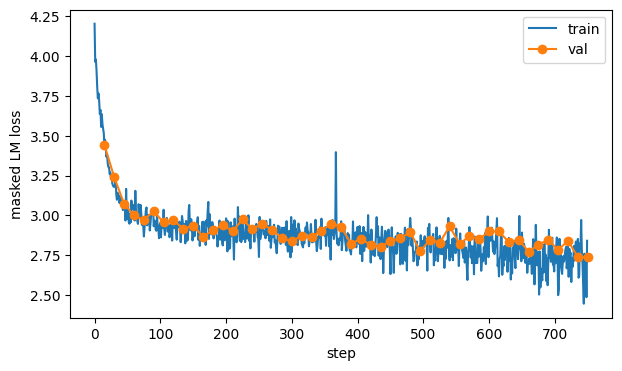

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, label='train')
if val_history:
    steps = [item[0] for item in val_history]
    values = [item[1] for item in val_history]
    plt.plot(steps, values, marker='o', label='val')
plt.xlabel('step')
plt.ylabel('masked LM loss')
plt.legend()
plt.show()

In [11]:
batch = val_loader.next_batch()
model.eval()
with torch.no_grad():
    output = model(
        batch['input_ids'],
        batch['residue_mask'],
        asym_id=batch['asym_id'],
        residue_index=batch['residue_index'],
        mol_type=batch['mol_type'],
    )

output['hidden_states'].shape, output['mlm_logits'].shape


(torch.Size([8, 64, 7, 128]), torch.Size([8, 64, 64]))

In [12]:
output['hidden_states'][:, :, -1].shape, output['hidden_states'][:, :, -1]

(torch.Size([8, 64, 128]),
 tensor([[[ 0.6504,  2.1114, -0.0753,  ...,  0.8803,  1.2189, -0.3073],
          [ 0.6578,  1.5275,  1.8180,  ..., -1.0127,  0.1828, -1.6530],
          [-0.7412,  2.4998,  0.3907,  ..., -0.7491,  0.4415, -1.5012],
          ...,
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
         [[ 0.0886,  1.1108, -0.4021,  ...,  1.3856,  1.7130, -0.4032],
          [ 1.2720,  1.0906,  1.3514,  ..., -1.1296,  0.6851, -2.2986],
          [ 0.3438,  1.6494,  0.3440,  ..., -0.9131,  0.7586, -2.4625],
          ...,
          [ 0.0000,  0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
         [[ 0.9711,  1.1712,  1.5818,  ..., -1.4137,  1.0912, -2.3623],
 

In [13]:
output['hidden_states'].shape, output['hidden_states']

(torch.Size([8, 64, 7, 128]),
 tensor([[[[-2.8114e-02, -4.6543e-03,  1.6726e-02,  ..., -2.7686e-02,
             3.3002e-02,  1.9819e-02],
           [ 5.3579e-02,  7.8735e-02, -1.1260e-01,  ...,  8.0868e-02,
             3.0977e-03,  1.3741e-01],
           [ 7.9745e-02,  1.4481e-01, -2.1314e-01,  ...,  2.6442e-01,
             5.5693e-02,  1.9119e-01],
           ...,
           [ 1.8237e-01,  4.5456e-01, -1.5642e-01,  ...,  2.7640e-01,
             2.2854e-01,  4.9128e-02],
           [ 1.8506e-01,  5.2526e-01, -1.1492e-01,  ...,  3.1304e-01,
             3.2523e-01, -8.6616e-04],
           [ 6.5043e-01,  2.1114e+00, -7.5329e-02,  ...,  8.8030e-01,
             1.2189e+00, -3.0735e-01]],
 
          [[-5.2395e-04, -2.9103e-02,  3.5253e-02,  ...,  1.7102e-02,
            -8.9801e-03,  3.1159e-02],
           [ 1.8678e-01,  2.3270e-01,  4.6535e-01,  ..., -2.6844e-01,
            -2.2234e-02, -1.4613e-01],
           [ 2.2281e-01,  3.5397e-01,  6.5490e-01,  ..., -5.3371e-01,
         

In [14]:
output['mlm_logits'].shape, output['mlm_logits']

(torch.Size([8, 64, 64]),
 tensor([[[-4.8220, -5.2395, -4.5418,  ..., -4.7600, -4.9173, -4.4331],
          [-4.6139, -5.4668, -4.6174,  ..., -4.6381, -5.0251, -4.2468],
          [-5.0713, -5.7097, -4.6566,  ..., -4.8150, -5.2265, -4.7658],
          ...,
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-4.7730, -5.2693, -4.3383,  ..., -4.5463, -4.7407, -4.2646],
          [-2.7672, -3.1033, -2.8050,  ..., -2.9471, -2.9603, -2.6917],
          [-4.2259, -4.9634, -4.2035,  ..., -4.1764, -4.5240, -3.8649],
          ...,
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-4.2626, -4.9241, -4.1976,  ..., -4.3662, -4.5795, -3.8698],
  